In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
%matplotlib inline
import time
import os

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
# import bioinfokit
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.model_selection import StratifiedKFold,KFold
logo = LeaveOneGroupOut()
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import pickle

In [2]:
%run classifiers_functions.ipynb

# All cells marked with * are not necessary to facilitate routine analysis, they are for you to modify according to your application-specific use

# Data import & selection

In [3]:
# change this directory to your folder

# os.chdir('D:/BOX/Box Sync/RA/codes/Imaging/ambient MSI')
os.chdir('G:\SPEC\Florine')
# os.chdir('E:/Data/Merck/Cell lines')
# os.chdir('D:/BOX/Box Sync/Publications/Riad/IJMS/Multimodal')



cwd = os.getcwd()
cwd

'G:\\SPEC\\Florine'

In [30]:
# features_from_file = np.loadtxt('D:/BOX/Box Sync/Publications/Riad/IJMS/pos_features.txt')
features_from_file = pd.read_csv('RFE_features_HR.csv').values
features_from_file.shape

(266, 1)

In [3]:
tmp_train, Data_train, mz = load_data('G:/SPEC/Stef/matrix_for_postprocessing.csv')
# Data_train = Data_train.iloc[3:,:]
tmp_train

# file.to_csv (r'D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/green_red_ROIs.csv', index = False, header=True)

data already has the same spectral variables


,Sample,Patient,Class,94.9259,99.9258,107.051,108.0206,109.0279,111.0081,111.0259,...,1188.6417,1190.0525,1190.2491,1193.043,1193.6782,1194.8777,1195.0559,1196.0095,1196.7346,1198.6846
0,GU496_1,GU496,control,0.000000,0.000000,0.000000,2923.825258,651.636199,1165.952809,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,304.292482
1,GU496_2,GU496,control,897.428958,0.000000,0.000000,3185.489253,0.000000,1407.669479,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,GU423_1,GU423,control,0.000000,0.000000,742.354066,2735.848875,1092.694782,1807.732791,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,GU423_2,GU423,control,0.000000,0.000000,0.000000,3273.558489,1315.200730,1932.761151,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,GU423_3,GU423,control,0.000000,0.000000,0.000000,3144.033129,1641.763439,2218.718241,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,GU437_duplicate_2,GU437,cancer,0.000000,0.000000,0.000000,9116.342843,3265.652904,4806.331221,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
77,GU473_duplicate_1,GU473,cancer,0.000000,0.000000,0.000000,8494.762459,3205.904646,3322.149933,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
78,GU466_duplicate_1,GU466,cancer,0.000000,0.000000,0.000000,5769.699682,2139.883977,3716.525240,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
79,GU466_duplicate_2,GU466,cancer,0.000000,461.632045,0.000000,6938.131776,1677.598501,2696.838059,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


# *Sub-grouping (e.g. to combine classes, here a demonstration is given on how the 'fat' and 'fibrous' classes were combined to be 'normal')


In [12]:
tmp_train_r = tmp_train.copy()
condition1 = (tmp_train['Mutation'] == 'Unknown')

# for i in range(0,len(tmp_train_r)):
#     tmp_train_r.loc[i, "Sample"] = tmp_train_r.loc[i, "Sample"].split('_')[0]
# Data_train_r = tmp_train_r.iloc[:,2:]
tmp_train_r = tmp_train_r[~condition1]
Data_train_r = tmp_train_r.iloc[:,3:]
# tmp_train_r['Label'] = np.random.permutation(tmp_train_r['Label'].values)
tmp_train_r

,Label,ID,Mutation,168.035585,171.4185659,171.6036103,197.7272597,205.0769662,212.1012187,217.0146386,...,736.6320844,737.9278017,761.2981248,767.3565676,767.5267279,768.3667266,773.5301342,792.7354846,806.3851142,824.5386914
17,KRAS,JLA039M_20150212_POLYP_B_MUCOSA.raw,p.Gly13Asp,176.287299,91.794991,74.072193,72.474741,856.544827,213.278495,65.769462,...,1357.032189,642.261408,767.620274,286.690766,1156.107262,1076.131074,628.000000,996.896183,245.987185,504.198424
18,KRAS,JLA039M_20150212_POLYP_B_MUCOSA.raw,p.Gly13Asp,141.896015,125.664328,122.574735,116.578599,781.965942,229.509241,70.426403,...,2615.764455,481.391748,1560.943500,795.818569,1648.259252,1472.490063,1088.285714,1179.174669,443.383511,597.097221
19,KRAS,JLA039M_20150212_POLYP_B_MUCOSA.raw,p.Gly13Asp,167.476302,141.092228,136.388287,123.527799,705.312378,213.464902,102.956089,...,2245.368960,450.530611,1308.070420,666.035700,1365.207654,1321.633025,940.055875,991.190518,366.572058,541.374821
20,KRAS,JLA039M_20150212_POLYP_B_MUCOSA.raw,p.Gly13Asp,139.322699,125.927253,117.423167,121.251562,693.090957,198.932634,111.253775,...,1962.528348,415.735948,1139.616291,612.566068,1237.278879,1068.331447,833.592644,915.258443,353.121937,482.303138
21,KRAS,JLA039M_20150212_POLYP_B_MUCOSA.raw,p.Gly13Asp,213.321704,124.634789,124.634789,131.203430,738.383085,226.507233,111.663257,...,2280.620555,2405.139503,1949.640173,1772.485438,1772.485438,2107.219675,1170.824638,1226.160194,425.617413,463.039090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,KRAS,JLA543_9_011118_P_CUT5.raw,p.Gln61Arg,209.227227,806.755944,670.957191,270.654568,1077.499545,875.387646,5694.200000,...,19184.533460,1819.001095,23909.493690,1571.300427,3743.149857,7469.955589,5229.583559,626.941152,1376.758576,860.713910
127,KRAS,JLA543_9_011118_P_CUT5.raw,p.Gln61Arg,206.472817,747.076292,602.891066,444.004631,1091.598008,1134.256799,4777.597109,...,17708.230780,2578.151097,21618.736640,1333.503359,3553.850011,8797.090284,4842.788745,555.876771,1346.625225,531.374205
128,KRAS,JLA543_9_011118_P_CUT6.raw,p.Gln61Arg,316.177582,798.818689,590.725466,182.287500,926.983047,762.247821,5229.400000,...,20300.129440,2398.098959,20573.894110,1160.661312,4694.621521,10725.972750,4721.372466,4721.263236,2344.791507,3015.478837
129,KRAS,JLA543_9_011118_P_CUT6.raw,p.Gln61Arg,400.273360,957.686909,499.594098,192.927671,1011.762047,693.894210,4206.521344,...,24085.386770,3137.401856,24479.864490,5764.090073,1939.529856,13468.727530,6738.253251,941.153416,1224.384818,871.233861


# *Randomly re-sample positive/negative to balance classes

In [7]:
from sklearn.utils.random import sample_without_replacement as resample

positives = (file['Label'] == 'Positive')
positives = file[positives]
negatives = (file['Label'] == 'Negative')
negatives = file[negatives]

# sample_50pos = resample (n_population=(len(positives)),n_samples=50)
# sample_50pos = positives
sample_50neg = resample (n_population=(len(negatives)),n_samples=68)

data_pos = positives
data_neg = negatives.iloc[sample_50neg,:]

frames=[data_pos, data_neg]
file_resample= pd.concat(frames)
Data_resample = file_resample.iloc[:,2:209]
# Data_resample = pd.concat(frames)
label = file_resample['Label'].tolist()

Data_resample

# Data pre-processing (i.e. extract common m/z & normalisation/scaling)

In [4]:
#define m/z axis

mz_trans=mz.transpose()
# mz_trans
mz_trans=np.reshape(mz_trans,(-1,1))
mz_trans.shape

(3902, 1)

In [5]:
# Normalisation/scaling
# options = median log transform(default), TIC normalisation, 
# SNV normalisation(don't usually use), MINMAX normalisation (don't usually use)
# you can of course 'stack' multiple normalisations, example given below TIC+median log

Data_n = data_norm(Data_train, method='tic')
# Data_n_s = data_norm(Data_train_s, method='tic')
Data_log = data_norm(Data_n, method='log')
# Data_log_s = data_norm(Data_train_s, method='log')
Data_log.shape

(81, 3902)

# Data visualisation

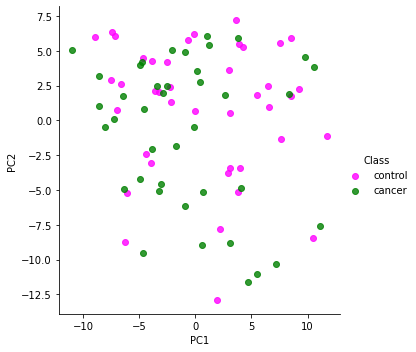

In [7]:
# sparse PCA
# use for cases when number of samples(e.g. patient) n << number of features(m/z) m

from sklearn.decomposition import SparsePCA
spca=SparsePCA(n_components=3,random_state=0)
sX_2D = spca.fit(Data_log).transform(Data_log)
sloadings = pd.DataFrame(spca.components_.T, columns=['PC1', 'PC2','PC3'])
sPCA_data=tmp_train
sPCA_data['PC1'] = sX_2D[:,0]
sPCA_data['PC2'] = sX_2D[:,1]
sPCA_data['PC3'] = sX_2D[:,2]
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
group_label = list(sPCA_data.columns)
sns.lmplot("PC1", "PC2", hue=group_label[2], data=sPCA_data, palette=colors, fit_reg=False)

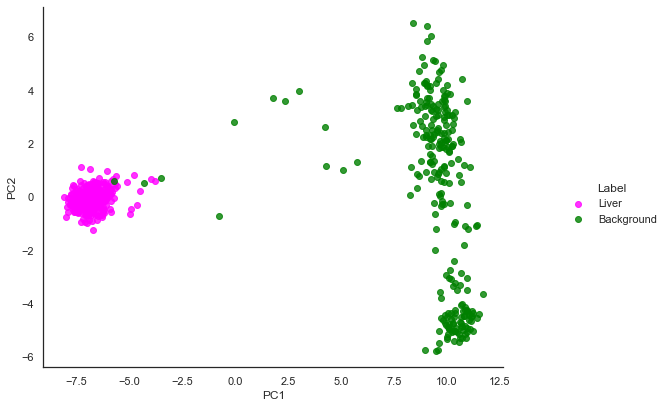

In [27]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=5) #keep first 3 components
X_2D = pca.fit(Data_log).transform(Data_log)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5'])

# label,y= np.unique(file['Label'],return_inverse = True)
# label=file['Label']
colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
# lw = 1

# PCA_data=tmp_train.copy()
PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]
PCA_data['PC4'] = X_2D[:,3]
PCA_data['PC5'] = X_2D[:,4]


sns.lmplot("PC1", "PC2", hue='Label', data=PCA_data, palette=colors,fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

#save it
# plt.savefig('D:/BOX/Box Sync/RA/data/IMAGING/LD_REIMS/from Vince/cambridge multiple sclerosis/for Luca/PCA_pos.eps', format='eps')

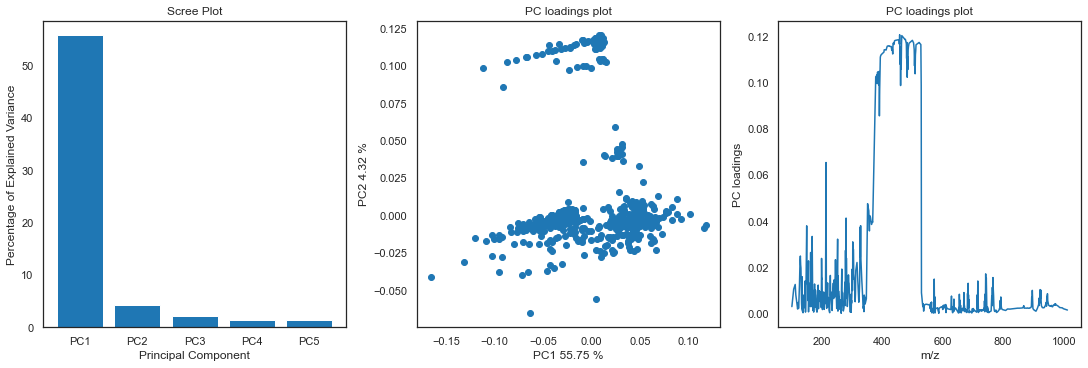

In [28]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC loadings plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(mz,loadings['PC2'].abs())
# axs[2].plot(mz,loadings['PC3'])
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('m/z')
axs[2].set_ylabel('PC loadings');


## 3D PCA (need to install plotly for this to work!)

In [29]:
import plotly.express as px

fig = px.scatter_3d(PCA_data, x='PC1', y='PC2', z='PC3',
              color='Label')
fig.update_traces(marker_size = 6)
fig.show()
#ax.scatter3D(xdata, ydata, zdata, c=file['Label'], label=file['Label']);
#fig = plt.gcf()
#fig.set_size_inches(12,6)

# Non-linear data visualisation

## t-SNE (select n_components depending on whether you want 2D or 3D plots)

In [8]:
%%time
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=3, init='pca',perplexity = 5,
                  learning_rate = 50).fit_transform(Data_log)
# X.dtype

Wall time: 1.17 s


### 2D plot

In [14]:
import plotly.express as px
fig = px.scatter(x=X_embedded[:,0], y=X_embedded[:,1], color=tmp_train['Class'],color_discrete_sequence=["magenta", "cyan"])
# fig.set_size_inches(10,6)
fig.update_layout(
        xaxis_title='t-SNE dimension 1',
        yaxis_title='t-SNE dimension 2',
    )
fig.show()

In [15]:
import plotly.express as px
fig = px.scatter_3d(x=X_embedded[:,0], y=X_embedded[:,1], z=X_embedded[:,2],
              color=tmp_train['Class'],color_discrete_sequence=["magenta", "cyan"])
fig.update_traces(marker_size = 8)
fig.update_layout(autosize=False,
        width=1000,
        height=800,
    scene = dict(
#         zaxis = dict(range=[-80,80]),
#     yaxis = dict(range=[-80,80]),
        xaxis_title='t-SNE dimension 1',
        yaxis_title='t-SNE dimension 2',
        zaxis_title='t-SNE dimension 3',
    ),
)
# fig.show()

## UMAP (set n_components similarly)

In [16]:
# Dimension reduction and clustering libraries
import umap.umap_ as umap
# import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.preprocessing import label_binarize

In [17]:
%%time
# target = label_binarize(tmp_train['Label'], classes=['AD', 'CTRL'])
clusterable_embedding = umap.UMAP(init = 'pca',
    n_neighbors=50,
    min_dist=0.5,
    spread = 0.6, 
    n_components=3
).fit_transform(Data_log)

Wall time: 13.5 s


In [22]:
import plotly.express as px
fig = px.scatter(x=clusterable_embedding[:,0], y=clusterable_embedding[:,1], color=tmp_train['Class'],color_discrete_sequence=["magenta", "cyan",'green','red','blue'])
# fig.set_size_inches(10,6)
fig.update_layout(
        xaxis_title='UMAP dimension 1',
        yaxis_title='UMAP dimension 2',
    )
fig.show()

In [18]:
import plotly.express as px
fig = px.scatter_3d(x=clusterable_embedding[:,0], y=clusterable_embedding[:,1], z=clusterable_embedding[:,2],
              color=tmp_train['Class'],color_discrete_sequence = ['royal blue','yellow','red','green','blue'])
fig.update_traces(marker_size = 8)
fig.update_layout(autosize=False,
        width=1000,
        height=800,
    scene = dict(
#         xaxis = dict(range=[-10,10]),
#         yaxis = dict(range=[-10,10]),
#         zaxis = dict(range=[-5,8]),
        xaxis_title='UMAP dimension 1',
        yaxis_title='UMAP dimension 2',
        zaxis_title='UMAP dimension 3',
    ),
)

## *Feature selection using PCA (only if you have clear linear separation within a component)

In [71]:
# PC=loadings['PC3']
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project B/mz.txt', mz,delimiter=',')
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project b/pc.txt', PC,delimiter=',') #for me to save the components

# sorted_loading_values = PC.abs().sort_values(ascending=False)
# # sorted_loading_values
# top_30_mz = sorted_loading_values[0:100].index
# top_30_mz
# PCA_features=mz[top_30_mz]
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_PCA_APCvsKRAS.txt', PCA_features,delimiter=',')

# Classification models

In [19]:
# get group sizes to be used for cost sensitivity if biased
column = tmp_train['Class']

labelnames = set(column)
labelnames = list(labelnames)

w = np.zeros(len(labelnames))
for i in range(0,len(labelnames)):
    group=tmp_train[column== labelnames[i]]
#     group=file_resample[column== labelnames[i]]
    w[i]=(len(group))
    print('group' + str(i) + ' sampe size: '+str(w[i])+'\n')

print('ratio: '+str(w/max(w)))
weights = {labelnames[0]:1.0, labelnames[1]:w[0]/w[1]}

labelnames

group0 sampe size: 40.0

group1 sampe size: 41.0

ratio: [0.97560976 1.        ]


['cancer', 'control']

## Train models with CV
## you can select the classifier ('method'), the cross-validation strategy ('cvsplit', ATM only LOGO or stratified K-fold) and implement a cost-sensitive approach (input 'weights')

## method available = 'LR'(Logistic Regression), 'LDA'(Liner Discriminant Analysis), 'KNN'(k-Nearest Neighbours), 'CART'(Decision Trees), 'NB'(Naiive Bayesian), 'SVM'(Support Vector Machine), 'RF'(Random Forest)

## CV strategies available = 'loo' (leave-one-group-out as specified by 'group' argument), 'kfold' (stratified, default k=10)

In [20]:
results = train_cv (Data_log, method='SVM', cvsplit='loo', 
                    label=column.tolist(), group=tmp_train['Patient'], weights = weights)

Method SVC(class_weight={'cancer': 1.0, 'control': 0.975609756097561},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 3.4097769260406494 seconds


## *Visualise CV splitting behaviour (for k-fold mostly)

ValueError: n_splits=10 cannot be greater than the number of members in each class.

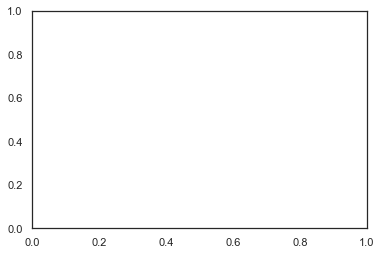

In [41]:
sns.set_context("notebook")
cvsplit = StratifiedKFold(n_splits=10)
old_label = tmp_train['Label'].copy()
old_group = tmp_train['ID'].copy()
plot_cv(cvsplit, Data_log, old_label, old_group, 16, lw=10)

## Model(s) evaluation - confusion matrix & ROC analysis

## if you want CM in sample numbers then just take away the 'normalize = true' during calculation

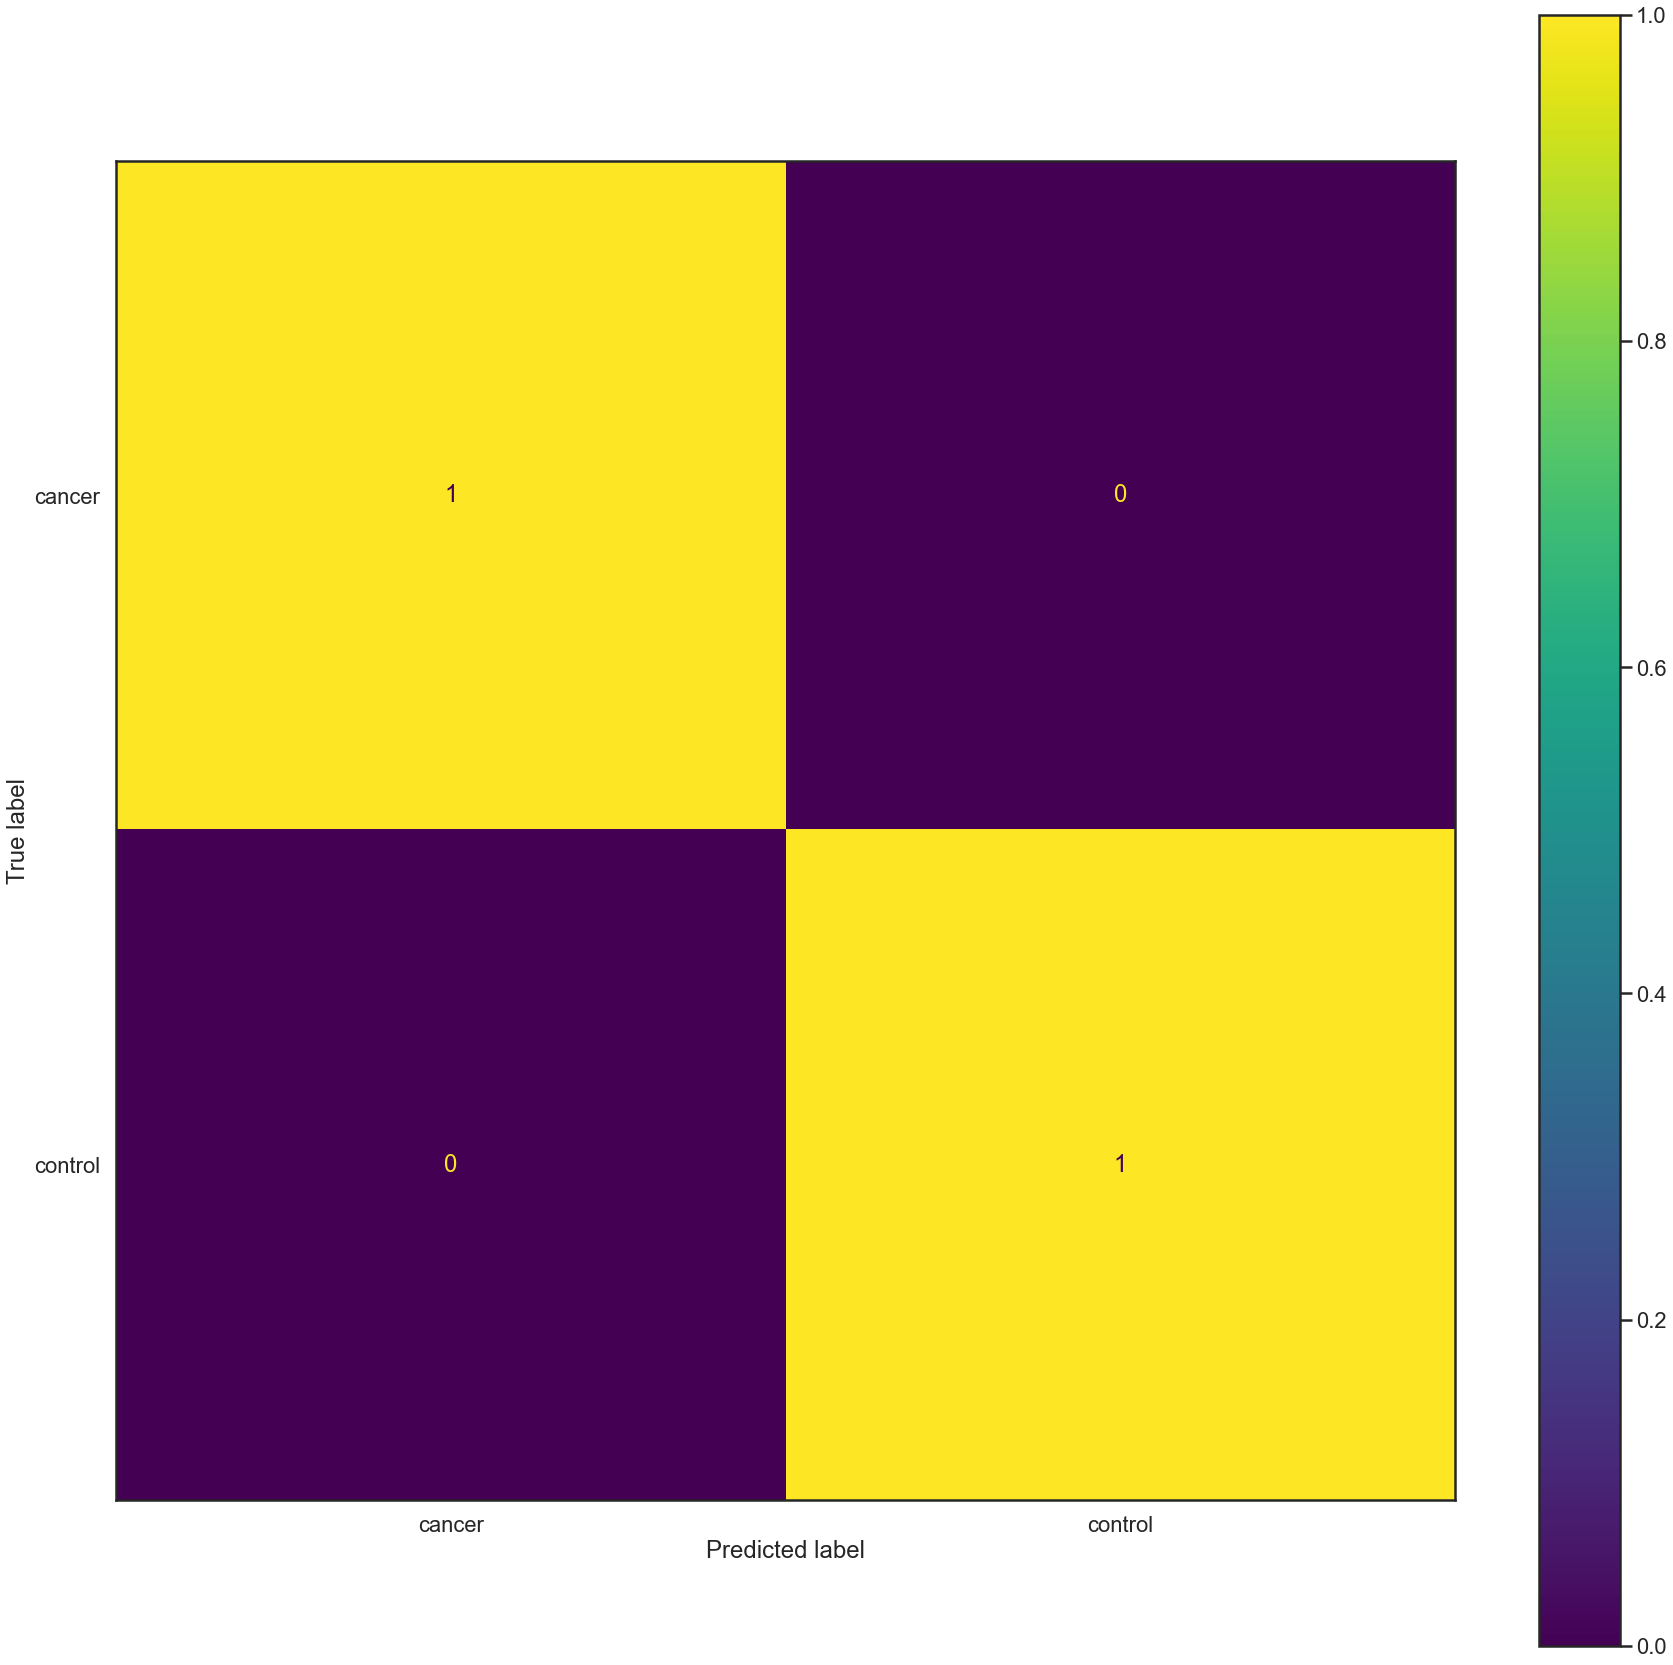

In [21]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.set_style("white")
sns.set_context("poster")
classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [22]:
performance = calculate_FPASS (CM,cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,cancer,1,1,1,1,1
1,control,1,1,1,1,1
2,Average,1,1,1,1,1


## ROC analysis - this will plot the 'macro average' if you have more than 2 classes, you can plot for a particular class by e.g. defining the input argument 'plotwhich=2' (so plot ROC for class 2); and in the case of k-fold, it currently plots a randomly selected 'fold' (i.e. the performance may change everytime you plot); you can also save the predicted probabilities by defining 'saveprobs=True'
## to-do: plot the average of k-fold

LOGO
there are 2 classes


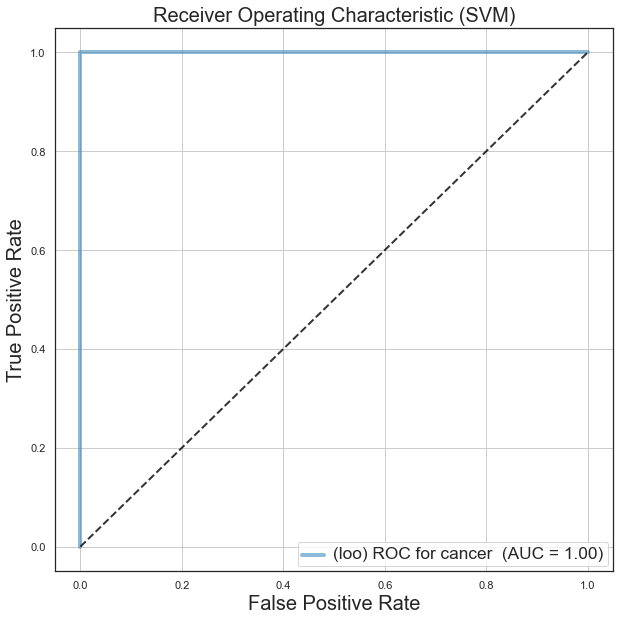

Wall time: 14.8 s


In [24]:
%%time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from random import randrange

[model, all_probs, all_y, FPRs, TPRs, AUCs] = do_ROC (Data_log, tmp_train['Class'].values, 
                                               group = tmp_train['Patient'].values, method='SVM', 
                                        cvsplit='loo', plotwhich = 0, saveprobs = False)

## *customising ROC curve plots

In [58]:
all_probs_1=all_probs.copy() 
all_y_1 = all_y.copy() 
FPRs_1 = FPRs.copy() 
TPRs_1 = TPRs.copy() 
AUCs_1 = AUCs.copy()

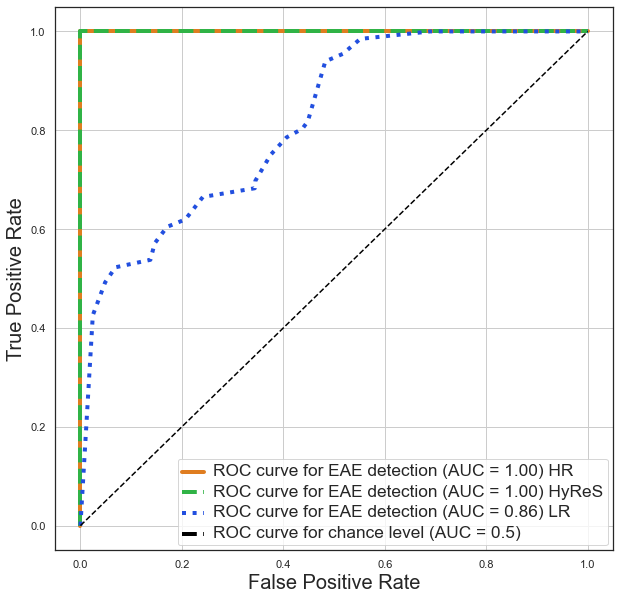

In [93]:
# TPRs = dict()
# FPRs = dict()
# AUCs = dict()
# for n in range(len(all_y)):
#     all_probs_n = all_probs[n]
#     all_y_n = all_y[n]
#     FPRs[n], TPRs[n], _ = roc_curve(all_y_n,all_probs_n[:,0],pos_label=cm_label[1])
#     AUCs[n] = auc(FPRs[n], TPRs[n])

    
# First aggregate all false positive rates
# all_fpr = np.unique(np.concatenate([FPRs[i] for i in range(len(all_y))]))

# # Then interpolate all ROC curves at these points
# mean_tpr = np.zeros_like(all_fpr)
# for i in range(len(all_y)):
#     mean_tpr += np.interp(all_fpr, FPRs[i], TPRs[i])

# mean_tpr /= len(all_y)
# mean_tpr[0] = 0.0

# FPRs["macro"] = all_fpr
# TPRs["macro"] = mean_tpr
# AUCs["macro"] = auc(FPRs["macro"], TPRs["macro"])

plt.figure(1, figsize=(10,10))
plt.plot(
    FPRs_1[0],
    TPRs_1[0],
    label='ROC curve for %s detection (AUC = %0.2f) HR' % (cm_label[0], AUCs_1[0]),
    color="#df7d20",
    linestyle="solid",
    linewidth=4,
)
plt.plot(
    FPRs_1[0],
    TPRs_1[0],
    label='ROC curve for %s detection (AUC = %0.2f) HyReS' % (cm_label[0], AUCs_1[0]),
    color="#30b346",
    linestyle='dashed',
    linewidth=4,
)
plt.plot(
    FPRs['macro'],
    TPRs['macro'],
    label='ROC curve for %s detection (AUC = %0.2f) LR' % (cm_label[0], AUCs[0]),
    color="#224fdf",
    linestyle='dotted',
    linewidth=4,
)
plt.plot([0, 1], [0, 1], "k--", label="ROC curve for chance level (AUC = 0.5)")
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate',fontsize=20)
plt.ylabel('True Positive Rate',fontsize=20)
leg = plt.legend(loc="lower right")
leg_lines = leg.get_lines()
leg_texts = leg.get_texts()
plt.setp(leg_lines, linewidth=4)
plt.setp(leg_texts, fontsize='x-large')
plt.grid()
plt.savefig("ROCs.pdf", format="pdf", bbox_inches="tight")
plt.show()



In [45]:
operation_ind = np.argmin(np.abs(TPRs['macro']-(1-FPRs['macro'])))
print('threshold sensitivity is %0.4f' % (TPRs['macro'][operation_ind]))
print()
print('threshold specificity is %0.4f' % (1-FPRs['macro'][operation_ind]))

threshold sensitivity is 0.0000

threshold specificity is 1.0000


# Save trained model & test new data

## the trained model will be saved to a folder called 'Trained_models', you can name the model to be anything (e.g. 'XXX.sav')

In [225]:
model_tosave = model
model_tosave.fit(Data_log, column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/SVM_test1.sav', 'wb'))

SVC(class_weight={'fibrous': 1.5416666666666667, 'tumour': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True)
saved


In [258]:
# load test data from file

tmp_test, Data_test, mz_test = load_data("OPO_data.csv", features = mz)
# Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test, method='log')
Data_test_log.shape

data already has the same spectral variables


(502, 1843)

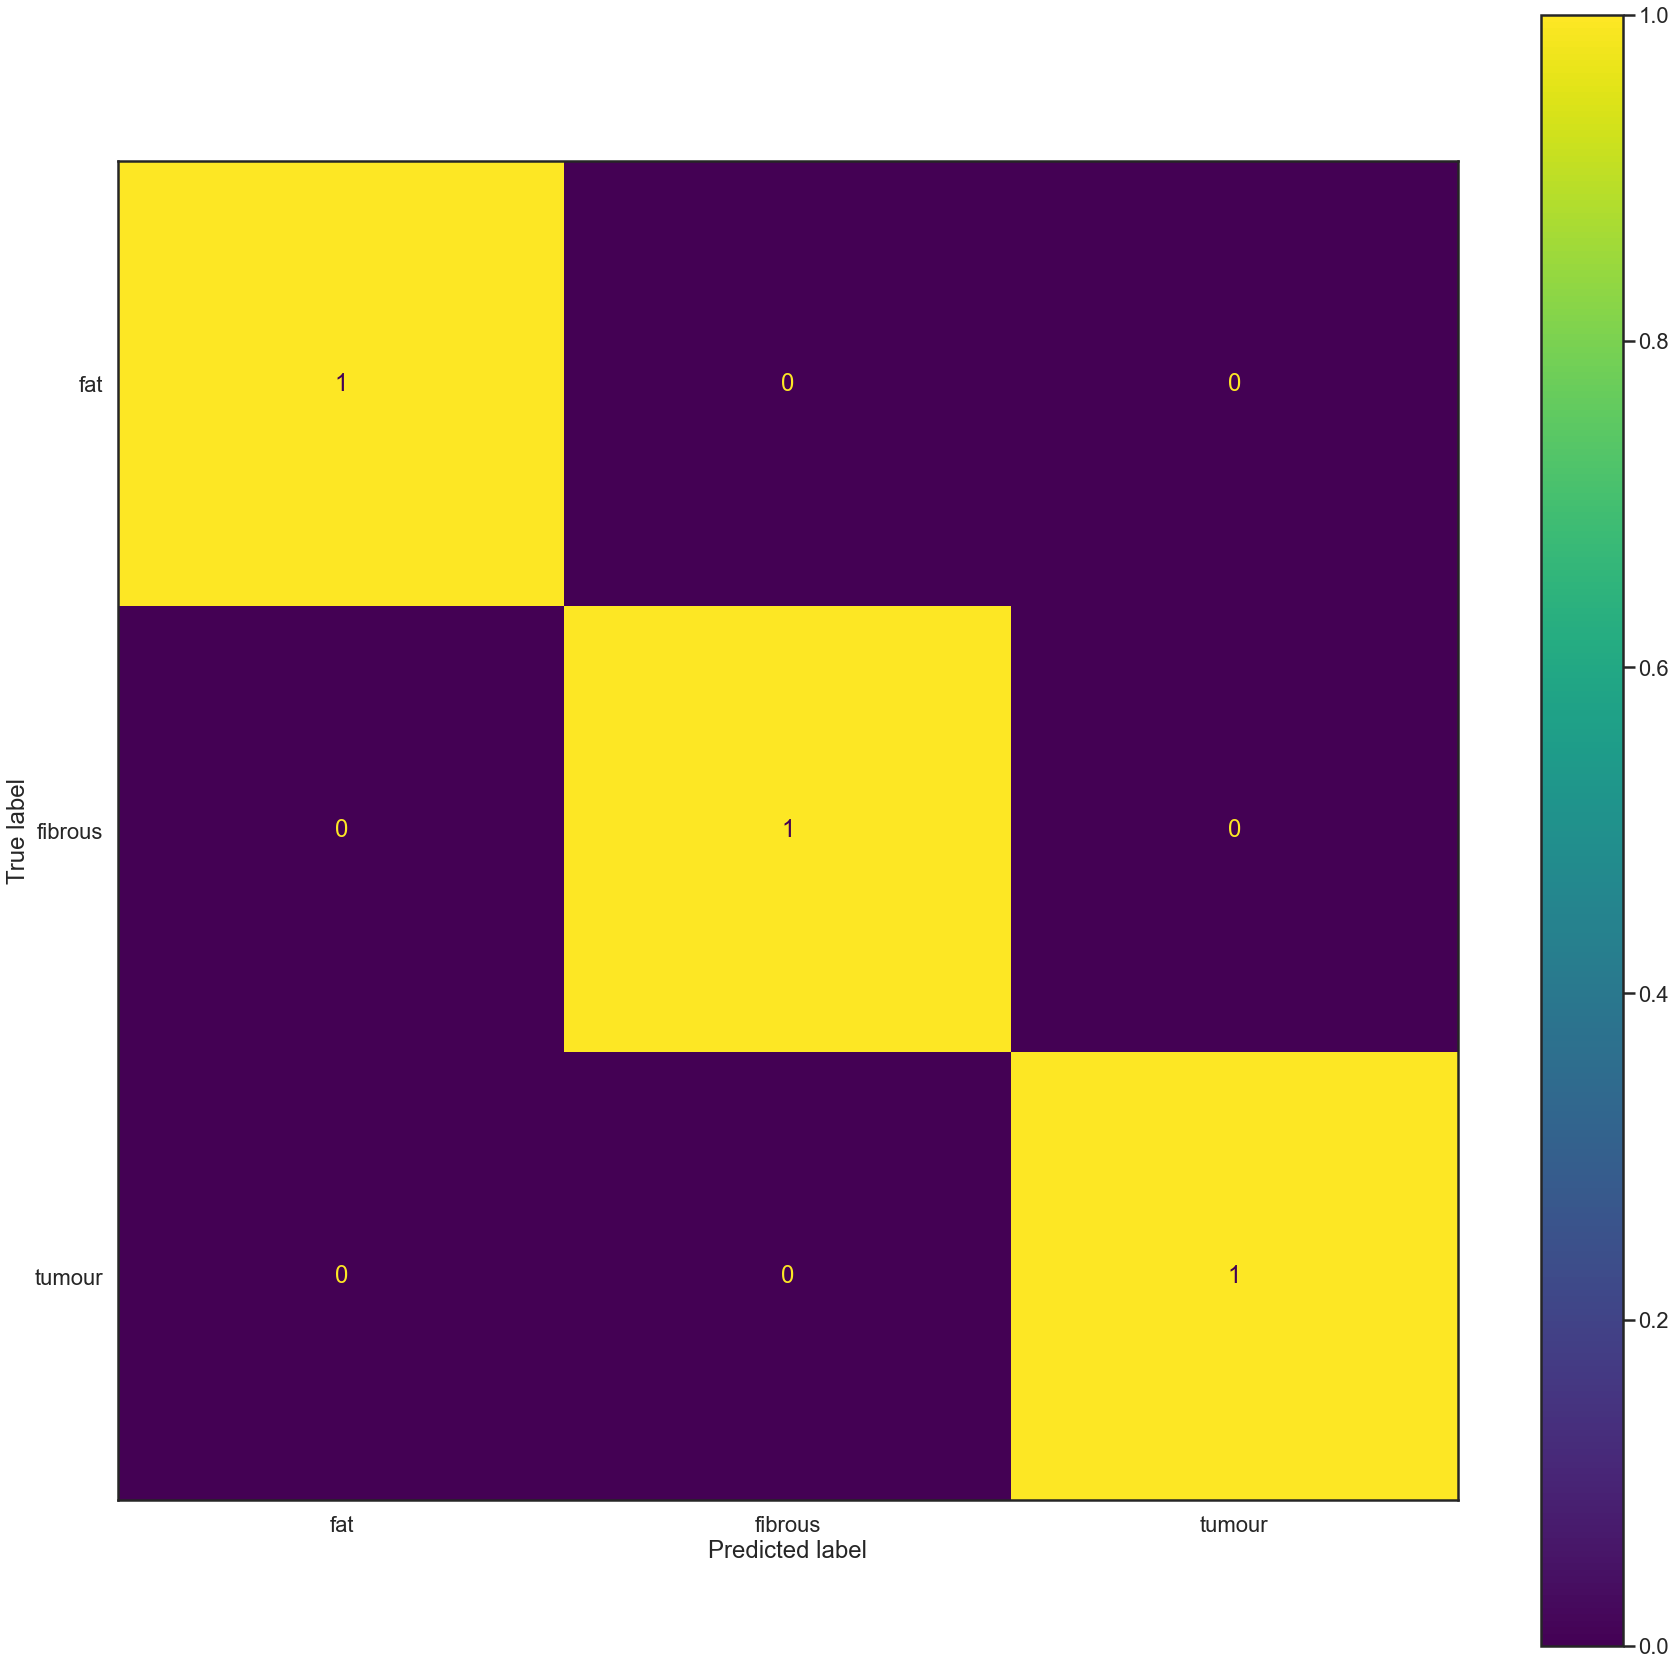

In [259]:
model_name = 'Trained_models/SVM_test1.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Label'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

## the CM alone can be 'deceiving' as most trained models are probabilistic and give the probabilities of a sample belonging to a certain class. If an inappropriate threshold was chosen (i.e. P>=threshold to be predicted to be a certain class), then the performance may appear to worsen when compared to CV results. To understand where this threshold should be, also check the ROC curves for the test data

there are 10 classes


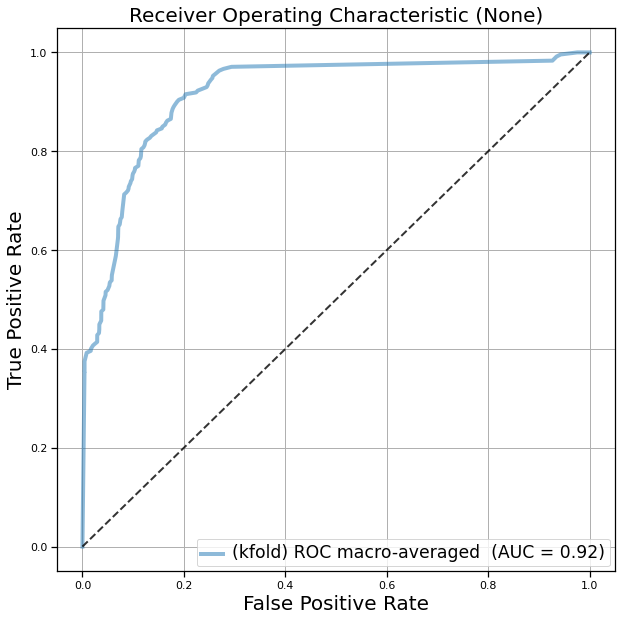

In [259]:
[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_test_log.values, tmp_test['Class'].values, saved_model = loaded_model,
        plotwhich = 'macro', saveprobs = True)

# Feature selection methods

## Feature selection with LR - there are 3 main methods:

## 1. Using the relative importance of LR coefficients obtained during model training; if you have more than 2 classes, then remember that LR CANNOT do true multi-class classification and instead it will do 'one-vs-rest' for as many times as you have classes. The output features are automatically saved (unless you turn it off with 'save = False') and you can define the number features (e.g. num_features = 50)

In [26]:
LR_features, importance = LR_importance(Data_log, tmp_train['Class'], num_features = 100, save=True)
print(LR_features)

           0
0   816.5748
1   919.7486
2   868.6028
3   891.7201
4   893.7337
..       ...
95  920.7510
96  894.4903
97  841.5319
98  874.4915
99  823.5656

[100 rows x 1 columns]


## *Feature selection for LR using log-likelihood test, only for binary classification!

In [39]:
from sklearn.metrics import log_loss
from scipy.stats import chi2

LR_features2 = LR_loglike(Data_log, tmp_train_r['Label'], threshold = 2.0, save = False)
LR_features2

array([  50.16054535,   52.30213547,   61.0007515 , ..., 1498.84692383,
       1499.19555664, 1500.20202637])

## Feature selection using RFE (Recursive Feature Elimination)
## standard RFE produces any defined number of features

In [117]:
# Here I chose 30 features

from sklearn.feature_selection import RFE
print(model)

RFE_features = RFE_select(Data_log, tmp_train['GD2 level'],n_features = 100)
RFE_features

SVC(class_weight={'low': 0.75, 'negative': 1.0}, decision_function_shape='ovo',
    kernel='linear', probability=True)

that took 3091.9161829948425 seconds


,0
0,146.980804
1,173.886902
2,174.029892
3,179.054596
4,187.129837
...,...
95,1404.042603
96,1404.809082
97,1455.775146
98,1464.857544


## if you are unsure how many features are necessary, use RFECV below as it will use a CV-based 'grid search' to also determine the optimal numer of features (5-fold by default), this is much slower!

In [23]:
# RFECV - use CV to determine & select best number of features

from sklearn.feature_selection import RFECV
print(model)

RFECV_features = RFECV_select(Data_log, tmp_train['Label'])
RFECV_features

SVC(class_weight={'EAE': 1.4398976982097187, 'HC_AL': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True)

that took 31106.702018260956 seconds


,0
0,89.024867
1,95.014085
2,95.952659
3,98.025018
4,99.045437
...,...
261,1002.730555
262,1003.735941
263,1027.749474
264,1096.764752


## Feature selection with LASSO (only for binary classification!)

In [189]:
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

lasso_features = LASSO_select(Data_log,tmp_train['Label'])
lasso_features

D:\anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



the LASSO classification accuracy was 0.0


,0


## Combine different FS approaches to generate a list of (overlapping) features & generate new data matrix with only these features

In [24]:
allfeatures = match_features([RFECV_features])
allfeatures

Data_train_s=np.zeros((len(Data_train),len(allfeatures)))
for n in range (0,len(allfeatures)):
    index= np.argmin(abs(mz-allfeatures[n]))
    Data_train_s[:,n]=Data_train.iloc[:,index]
    
output = pd.DataFrame(data=Data_train_s)
output['Label'] = tmp_train['Label']
# output['ID'] = tmp_train['ID']
i = 0
for mz_i in allfeatures:
    mz_i = float(mz_i)
    output = output.rename(columns={i: (mz_i)})
    i = i+1
output

,89.0248674964413,95.0140849069683,95.9526592154172,98.025017681782,99.0454365708985,101.024704882246,102.056835440976,104.036354507224,111.009126655567,111.045316956942,...,988.719791163679,999.71416648874,1000.71631810222,1001.72755830299,1002.73055482228,1003.73594053854,1027.7494736234,1096.76475159494,1114.76598620021,Label
0,212.0,178.0,0.0,386.0,182.0,137.0,231.0,0.0,291.0,473.0,...,70.0,114.0,119.0,201.0,145.0,162.0,0.0,0.0,0.0,EAE
1,127.0,143.0,0.0,550.0,90.0,190.0,261.0,0.0,407.0,0.0,...,85.0,100.0,234.0,99.0,64.0,131.0,0.0,0.0,0.0,EAE
2,64.0,125.0,0.0,260.0,255.0,296.0,350.0,0.0,349.0,359.0,...,186.0,154.0,127.0,440.0,144.0,41.0,116.0,0.0,0.0,EAE
3,0.0,103.0,0.0,256.0,84.0,145.0,274.0,93.0,307.0,258.0,...,0.0,110.0,95.0,310.0,223.0,85.0,0.0,25.0,0.0,EAE
4,0.0,265.0,0.0,216.0,122.0,152.0,369.0,0.0,500.0,361.0,...,145.0,108.0,90.0,391.0,237.0,0.0,0.0,0.0,0.0,EAE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082,67.0,102.0,0.0,225.0,0.0,125.0,243.0,0.0,245.0,261.0,...,0.0,0.0,0.0,0.0,66.0,0.0,0.0,0.0,0.0,HC_AL
1083,0.0,69.0,0.0,259.0,87.0,67.0,109.0,0.0,288.0,301.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,HC_AL
1084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,HC_AL
1085,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,HC_AL


## Save new data matrix

In [502]:
output.to_csv (r'data_select_filt.csv', index = False, header=True)
output

,168.035584992603,171.418565932919,171.603610282714,197.727259687626,205.076966169751,212.101218710721,217.014638649614,217.093092451997,221.136909698311,232.676247420903,...,761.298124822832,767.35656764718,767.526727925244,768.36672663096,773.530134200396,792.735484551379,806.385114157677,824.538691355837,Label,ID
0,94.609542,184.741536,184.741536,146.430590,11975.500000,1146.877859,106.531388,106.531388,1232.776734,536.704802,...,333.928059,1144.443841,536.386459,730.123519,1421.681261,1059.632218,518.889363,507.569350,none,JLA003_20150119_COLON_TUMOUR_S13B.raw
1,139.635105,309.131005,163.952673,118.932274,11900.500000,1214.122995,110.059845,110.059845,1167.297207,347.816206,...,1623.787999,1516.742183,1516.742183,892.414085,1806.027021,700.558154,380.066594,535.587494,none,JLA003_20150119_COLON_TUMOUR_S13B.raw
2,152.457042,295.242393,148.180826,95.464670,12335.166667,1169.281215,132.689661,132.689661,1103.741927,345.700863,...,2233.293261,1879.850166,1879.850166,987.384223,2320.499707,525.787324,444.030417,638.526017,none,JLA003_20150119_COLON_TUMOUR_S13B.raw
3,144.803309,320.032202,180.392340,109.369202,11861.687500,1075.894666,142.805503,142.805503,1106.427252,322.762416,...,1936.432246,1803.751126,1803.751126,1352.733137,2079.805206,460.199752,447.965419,589.772621,none,JLA003_20150119_COLON_TUMOUR_S13B.raw
4,155.903008,295.717222,177.423045,164.731917,8698.611583,1091.114314,151.989395,151.989395,1114.403595,342.502484,...,1900.739928,1256.805246,1952.538729,1479.536061,2176.016911,411.971856,699.127424,657.642526,none,JLA003_20150119_COLON_TUMOUR_S13B.raw
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,209.227227,806.755944,670.957191,270.654568,1077.499545,875.387646,5694.200000,5694.200000,8562.000000,377.299684,...,23909.493685,1571.300427,3743.149857,7469.955589,5229.583559,626.941152,1376.758576,860.713910,KRAS,JLA543_9_011118_P_CUT5.raw
127,206.472817,747.076292,602.891066,444.004631,1091.598008,1134.256799,4777.597109,4777.597109,7656.139859,290.427094,...,21618.736638,1333.503359,3553.850011,8797.090284,4842.788745,555.876771,1346.625225,531.374205,KRAS,JLA543_9_011118_P_CUT5.raw
128,316.177582,798.818689,590.725466,182.287500,926.983047,762.247821,5229.400000,5229.400000,8279.400000,318.606193,...,20573.894105,1160.661312,4694.621521,10725.972749,4721.372466,4721.263236,2344.791507,3015.478837,KRAS,JLA543_9_011118_P_CUT6.raw
129,400.273360,957.686909,499.594098,192.927671,1011.762047,693.894210,4206.521344,4206.521344,8180.600000,482.310934,...,24479.864493,5764.090073,1939.529856,13468.727534,6738.253251,941.153416,1224.384818,871.233861,KRAS,JLA543_9_011118_P_CUT6.raw


## Train & evaluate new model with only selected features

In [500]:
results = train_cv (Data_log_s, method='SVM', cvsplit='loo', 
                    label=column.tolist(), group=tmp_train_r['ID'], weights = weights)

Method SVC(class_weight={'KRAS': 1.0, 'none': 1.62}, decision_function_shape='ovo',
    kernel='linear', probability=True) iteration 0 
that took 0.14237213134765625 seconds


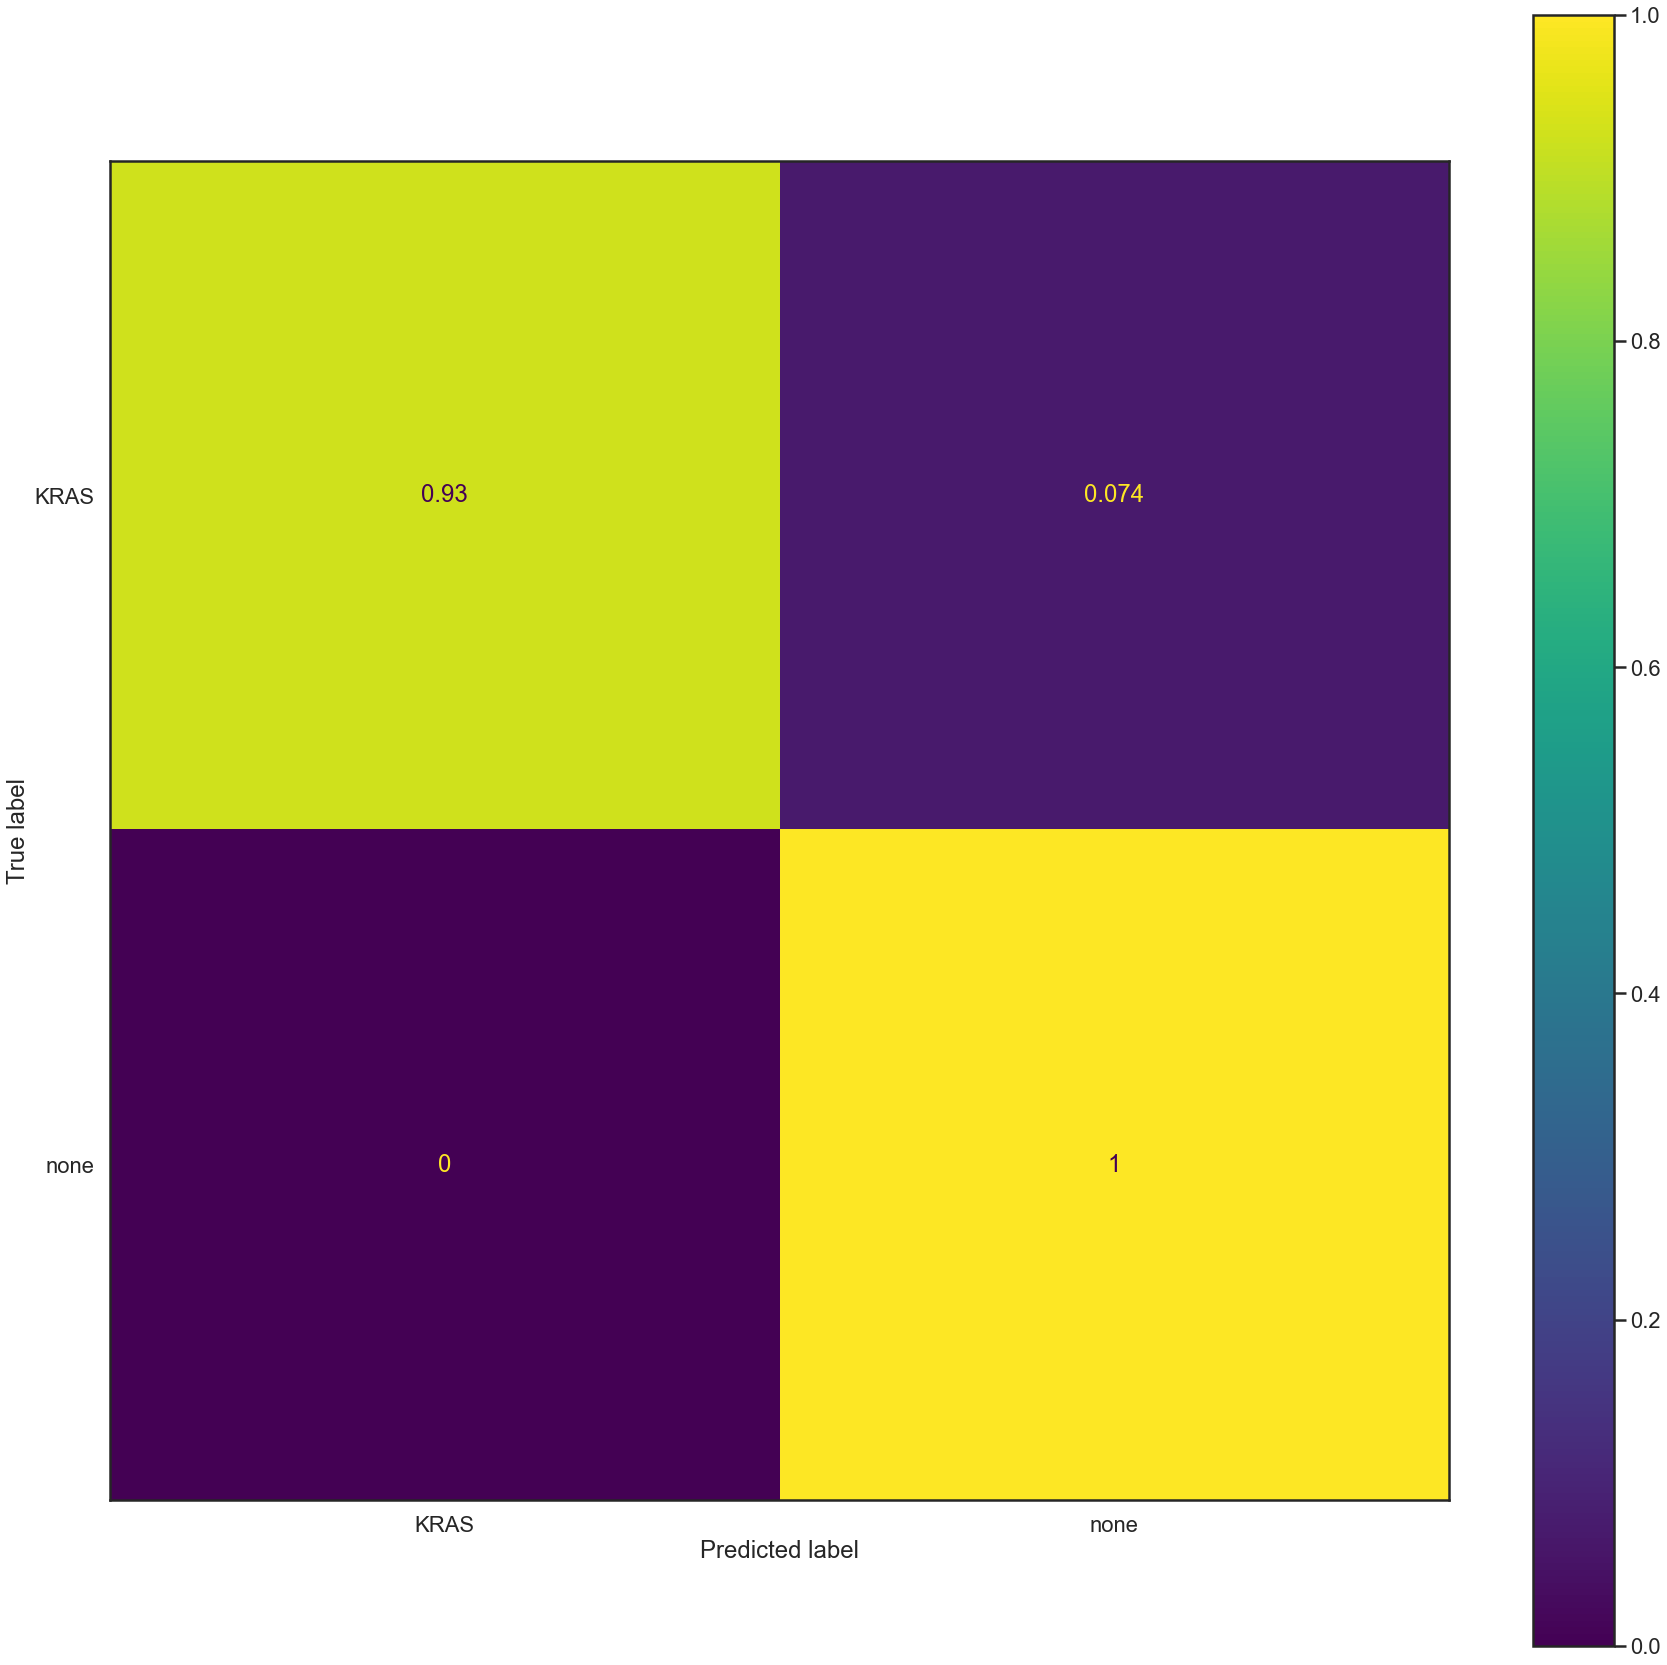

In [501]:
sns.set_context("poster")

classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [389]:
performance = calculate_FPASS (CM,cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,KRAS,1,1,1,1,1
1,none,1,1,1,1,1
2,Average,1,1,1,1,1


kfold


d:\anaconda3\lib\site-packages\ipykernel_launcher.py:66: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
d:\anaconda3\lib\site-packages\ipykernel_launcher.py:67: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


there are 3 classes


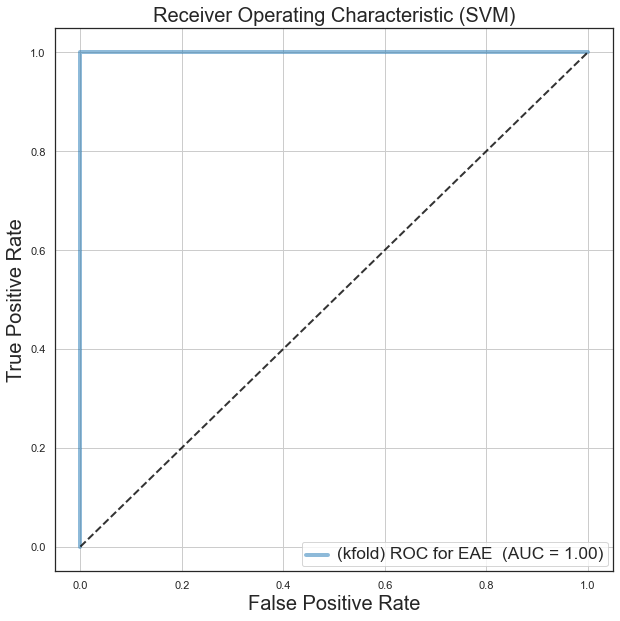

ValueError: Shape of passed values is (10, 1), indices imply (10, 3)

In [29]:
[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_log_s, tmp_train['Label'].values, 
                                               group = tmp_train['Label'].values, method='SVM', 
                                        cvsplit='kfold', plotwhich = 0, saveprobs = True)

## Save new model with only selected features

In [222]:
model_tosave = model
model_tosave.fit(data_norm(Data_train_s, method='log'), column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/SVM_test.sav', 'wb'))

SVC(class_weight={'fibrous': 1.5416666666666667, 'tumour': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True)
saved


## Load data and test with new model

In [223]:
tmp_test, Data_test,mz_test = load_data("OPO_data.csv", features = allfeatures)
# Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test, method='log')
Data_test_log.shape

test data truncated to include only selected spectral features within (100.00) ppm


(502, 204)

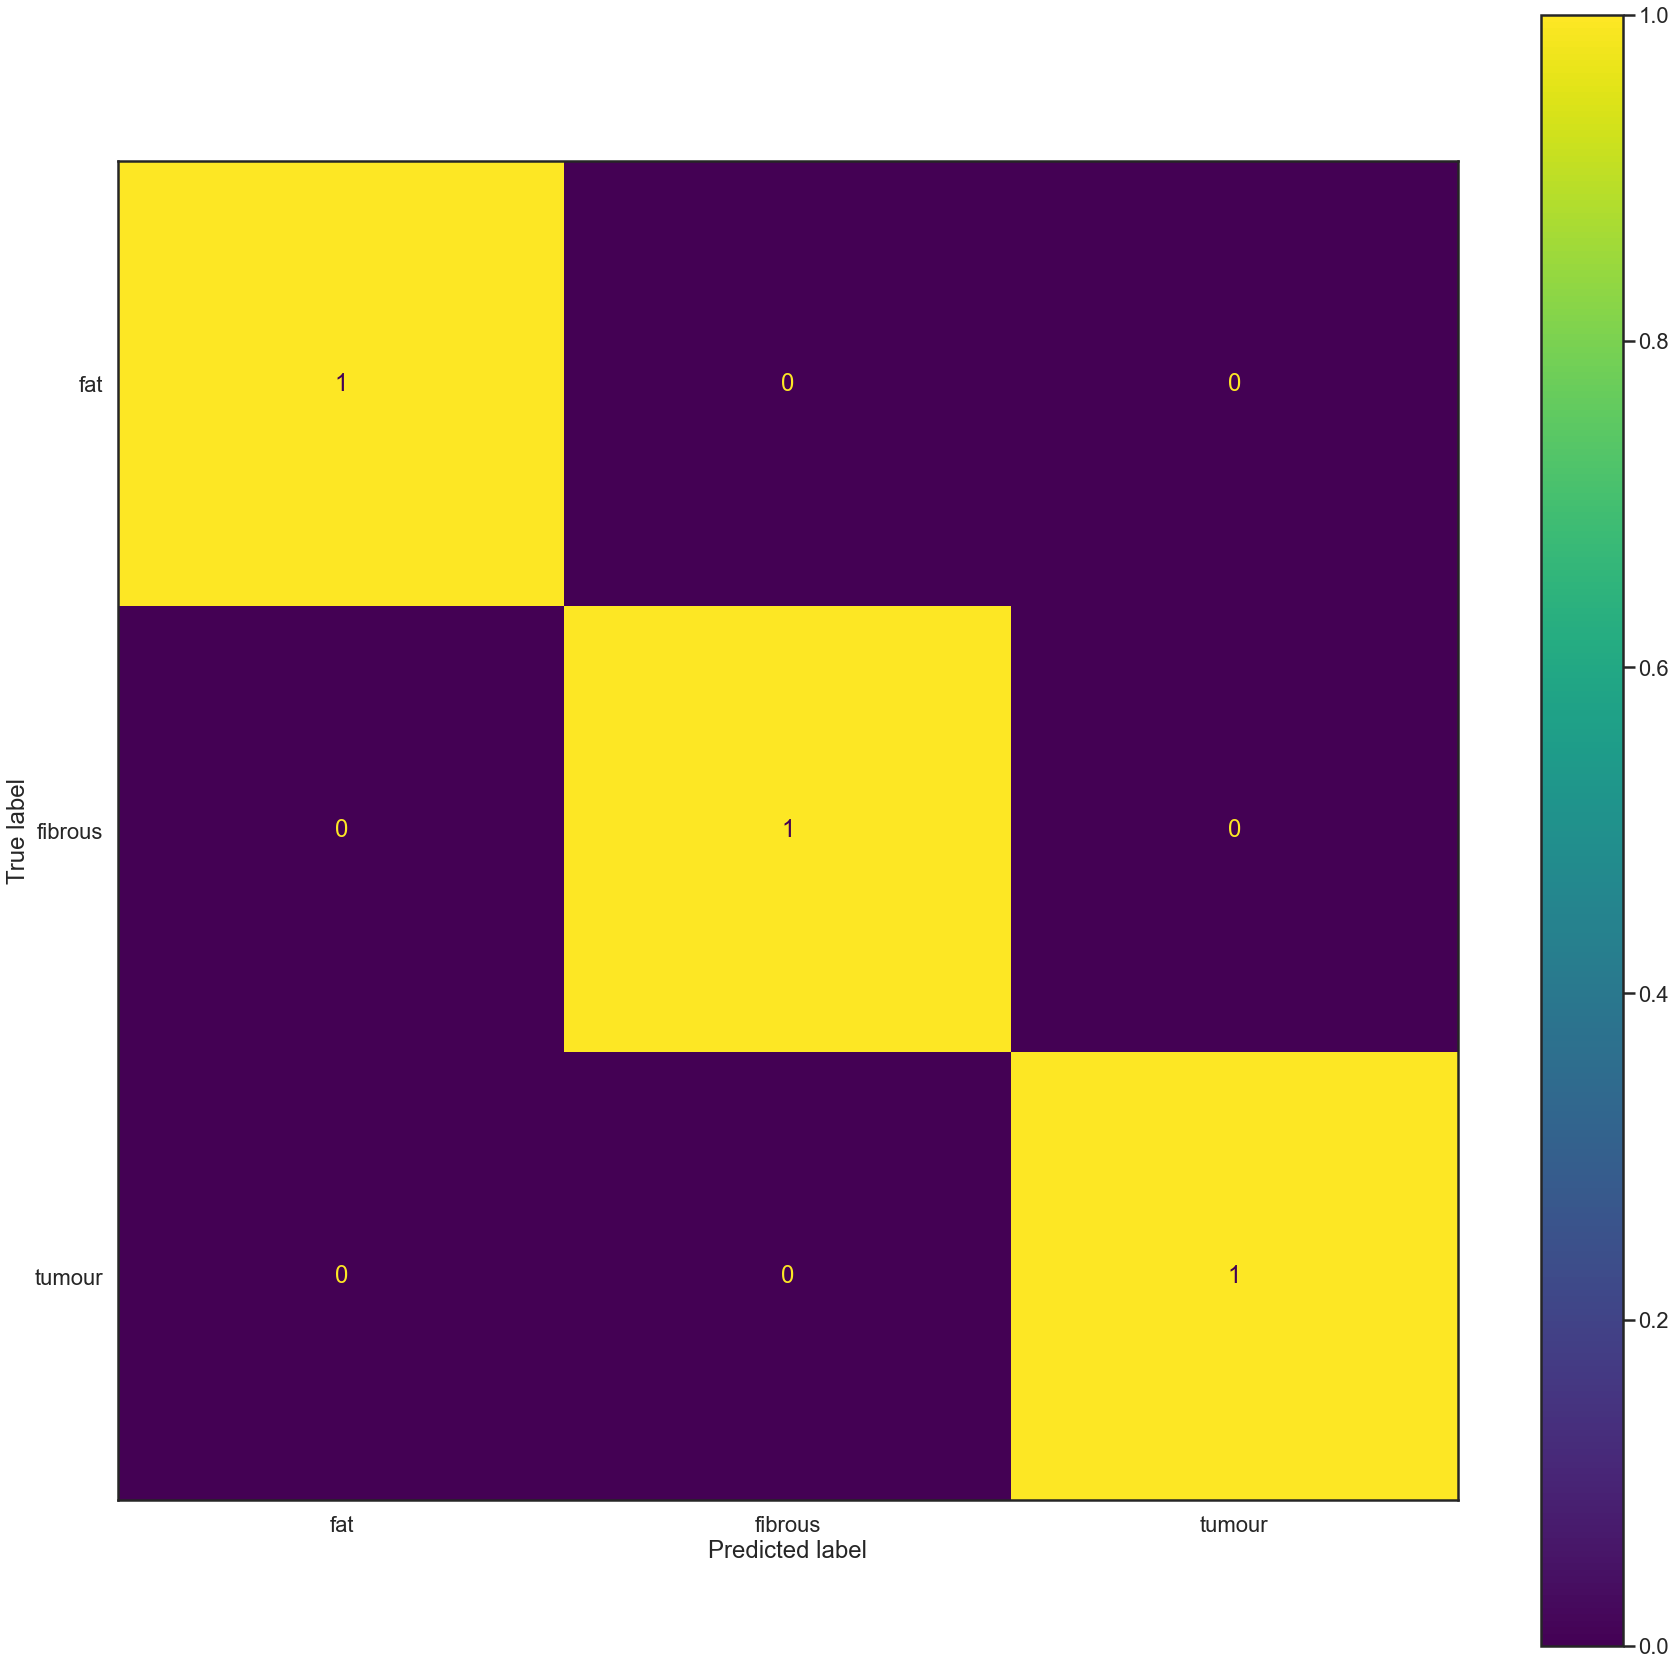

In [224]:
model_name = 'Trained_models/SVM_test.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Label'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

# Feature selection with univariate analysis

## Kruskal-Wallis test (non-parametric for multiple groups)

In [13]:
from bioinfokit import analys, visuz
from scipy import stats

green = labelnames[0]
red = labelnames[1]
green_data=Data_log[tmp_train['Label']== green]
green_data = pd.DataFrame(green_data)
red_data=Data_log[tmp_train['Label']== red]
red_data = pd.DataFrame(red_data)
print('comparing '+ green+' & '+red)

p_vals_KW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_KW[i]=1
    else:
        dum1=stats.kruskal(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_KW[i]=(dum2)        

comparing Eosinphilic & Control


## *Mann-Whitney test (non-parametric binary problem)

## KW test = MW test for a two-way comparison~

In [47]:
p_vals_MW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_MW[i]=1
    else:
        dum1=stats.mannwhitneyu(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_MW[i]=(dum2)

## FDR correction

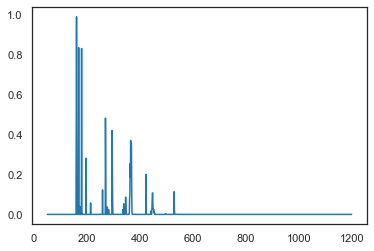

In [14]:
[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method='indep', is_sorted=False)
correct_p=np.where(correct_p==0, 1e-15, correct_p) 
plt.plot(mz,correct_p)
# p_vals.shape

## *features can be selected based on corrected p-values alone or using volcano plot (below)

In [67]:
p_threshold = 0.05
features = [correct_p <= p_threshold]
features_KW = mz[tuple(features)]
features_KW

array([  61.0007515 ,   69.17650604,   85.27057648, ..., 1498.84692383,
       1499.19555664, 1500.20202637])

## fold changes calculation for volcano plot

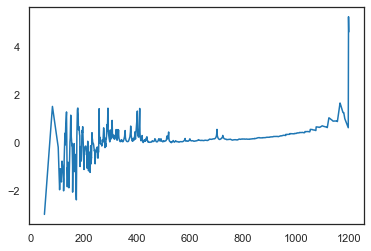

In [15]:
green_mean=np.mean(Data_train[tmp_train['Label']== green])
green_mean=np.where(green_mean==0, 1, green_mean) 
red_mean=np.mean(Data_train[tmp_train['Label']== red])
red_mean=np.where(red_mean==0, 1, red_mean) 

fc=green_mean/red_mean
log2fc=np.log2(fc)

plt.plot(mz,log2fc)

## plot and save volcano plot
## working example: https://www.reneshbedre.com/blog/volcano.html

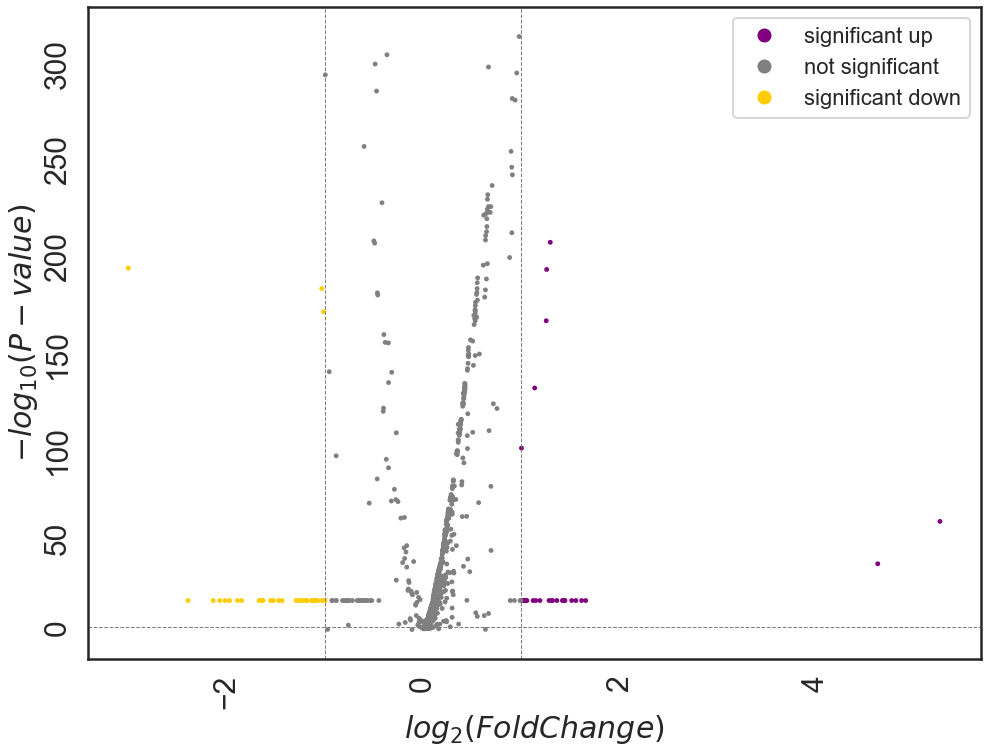

In [16]:
mzlabel=[''] * len(mz)
for i in range(len(mz)):
    mzlabel[i]=str(mz[i])

volcano_data=pd.DataFrame(index=range(0,len(mz)),columns=['pvals','fc','mz'])
volcano_data.iloc[:,0]=correct_p
volcano_data.iloc[:,1]=log2fc
volcano_data.iloc[:,2]=mzlabel
top30=volcano_data['pvals'].sort_values(ascending=True)
top30 = top30[0:30].index
# labels=mz[top30]
labels=np.array2string(mz[top30],separator=',',precision=12)

sns.set_context("poster")
sns.set_style("white")
fig = visuz.GeneExpression.volcano(df=volcano_data, lfc='fc', pv='pvals',geneid='mz', dim = [16,12],
                                   lfc_thr=(1, 1), pv_thr=(0.05, 0.05),
#                              genenames=({
# '205.076966169751':'metabolite1',
#  '574.263156979326':'lipid1'
# }),
color=("purple", "grey", "#FFCC00"), gstyle = 1, gfont = 12.0, plotlegend=True,legendpos='upper right',
                                   axtickfontsize = 30,axlabelfontsize=30, sign_line=True,show=True)

## select features according volcano plot thresholds

In [18]:
p_threshold = 0.05
fc_threshold = 1
condition=(volcano_data['pvals'] <= p_threshold) & (abs(volcano_data['fc']) >= fc_threshold)
vol_features=pd.DataFrame(mz[condition])

vol_features
vol_features.to_csv (r'vol_features.csv', index = False, header=True)

# Box plotting

## save box plots of selected features to defined path
## syntax: box_plot(list of features, mz, filename, column name to use for labels, save (True or False), savepath)

In [67]:
# features_from_file = np.loadtxt('features_OPO.txt')
features_from_file = pd.read_csv('D:/BOX/Box Sync/Publications/HyReS/Data/section2.3/cq_section2.3.csv')
features_from_file

,LR,HR,HyReS
0,47.200311,43.983265,60.002813
1,46.969304,43.985390,56.222450
2,45.077787,44.026028,48.741519
3,46.535446,45.096887,61.754659
4,43.499048,46.285400,54.433316
...,...,...,...
295,41.898802,42.405754,36.942618
296,41.552046,42.424792,41.094278
297,42.140197,42.297463,39.706560
298,41.688164,42.134122,44.840329


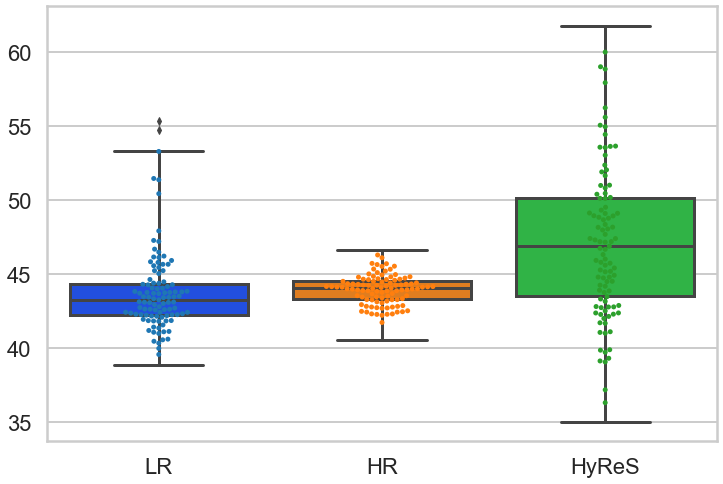

In [68]:
sns.set_style("whitegrid")
sns.set_context("poster")
fig = plt.figure(figsize=(12,8))
sns_plot = sns.boxplot(data=features_from_file, whis=5, palette = 'bright')
sns.swarmplot(data=features_from_file.sample(n=100, random_state=1))
# sns_plot = sns.violinplot(data=features_from_file, whis=5, palette = 'bright', scale = 'count', bw=1 )
sns_plot.figure.savefig('D:/BOX/Box Sync/Publications/HyReS/figures/box_section2.3.png',dpi=600)
# plt.ylim([0,1200])

In [26]:
box_plot(features_from_file.values, mz, tmp_train,'Label', save=True, savepath = 'G:/IMAGING/LD_REIMS/Shahd')
# box_plot(['303.9'], mz, tmp_train,'Class', save=False, savepath = 'E:/Data/Dani')

data too large! plotting using randomised 30% data points.
plot for [80.97003937] saved.
plot for [108.0214157] saved.
plot for [109.0313644] saved.
plot for [110.0245667] saved.
plot for [111.0071716] saved.
plot for [113.0224762] saved.
plot for [115.0778351] saved.
plot for [116.0342407] saved.
plot for [121.0285645] saved.
plot for [123.0054016] saved.
plot for [123.0825348] saved.
plot for [124.0146255] saved.
plot for [125.0211105] saved.
plot for [133.0235901] saved.
plot for [134.0469666] saved.
plot for [137.0352936] saved.
plot for [138.0523224] saved.
plot for [139.0031891] saved.
plot for [141.0167084] saved.
plot for [143.1058502] saved.
plot for [144.1107635] saved.
plot for [145.0822449] saved.
plot for [150.0411377] saved.
plot for [157.1225586] saved.
plot for [158.1265717] saved.
plot for [164.0449066] saved.
plot for [165.0392303] saved.
plot for [170.0559387] saved.
plot for [171.1378479] saved.
plot for [175.0936279] saved.
plot for [176.0692596] saved.
plot for [1